# Lab 1 Report:
## Hello PyTorch: Fit Your First Model

### Name:

### Lab Overview (3 hours)

This lab accompanies the lecture **Machine Learning & Neural Networks: Least Squares, Evolved**. You will prepare a dataset, split it, and then fit your first neural network in PyTorch by minimizing the Mean Squared Error (least squares) with gradient descent.

| Part | Topic | Time |
|---|---|---|
| Setup | Import libraries | ~10 min |
| Part 1 | Scaling Data with Standard Scaling (CMS calorimeter dataset) | ~50 min |
| Part 2 | Data Splitting and the Iris Dataset | ~50 min |
| Part 3 | Iris Classification using Regression (your first PyTorch model) | ~50 min |
| Bonus | Optional challenges for advanced students | optional |

**How to complete this lab**
* Run the cells from top to bottom (select a cell and press `Shift + Enter`).
* Look for the comment **`# Write your codes`**. Replace it with your code. Each prompt comes with a **Hint** that shows the code you need.
* Cells without `# Write your codes` are already complete. Just run them.
* Each part uses results from the part before it, so do not skip cells.

## Setup (~10 min)

In [69]:
# Import necessary libraries

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

In [70]:
from IPython.display import Image # For displaying images in colab jupyter cell

---
# Part 1: Scaling Data with Standard Scaling (~50 min)

| Task | Description | Time |
|---|---|---|
| 1.1 | Load the CMS calorimeter dataset | ~10 min |
| 1.2 | Extract the x, y, z, eta, phi and energy columns | ~10 min |
| 1.3 | Write the `scale_data()` function | ~20 min |
| 1.4 | Plot the scaled data | ~10 min |

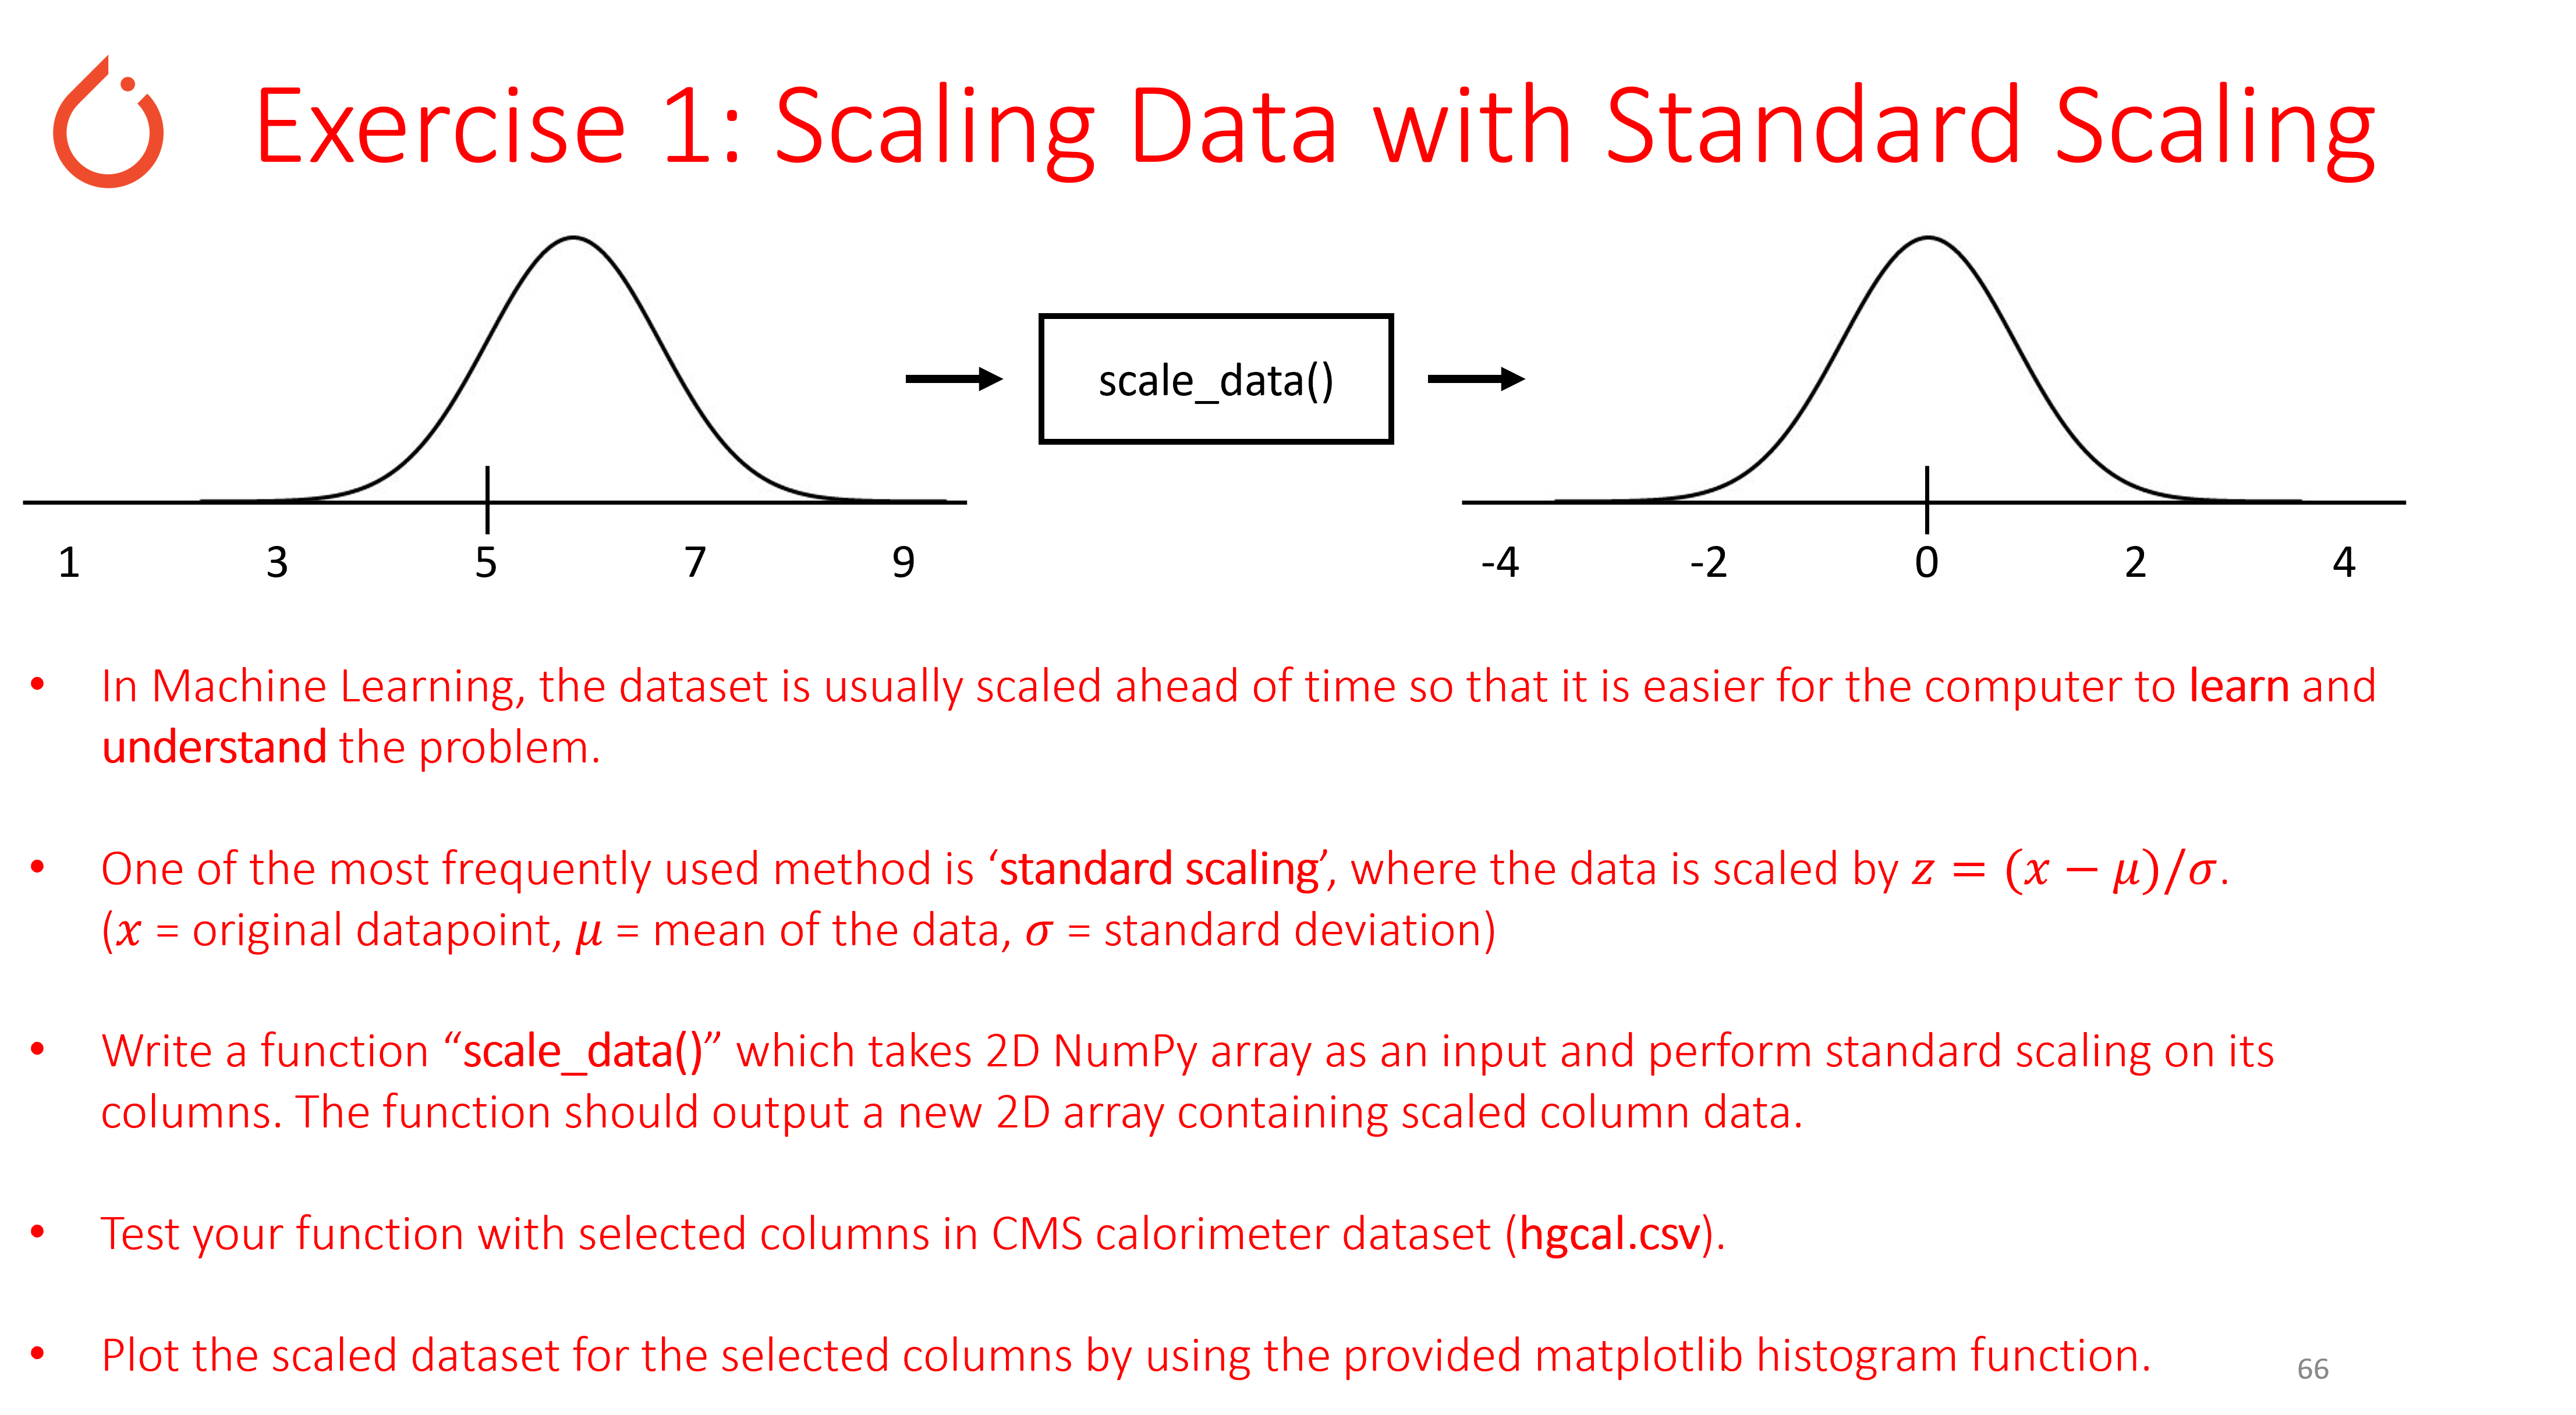

In [71]:
Image('lab1_exercise1.png', width = 1000)

## Task 1.1: Load Data

In [72]:
# Load the dataset (.csv) using pandas package

CMS_calori_dataset = pd.read_csv('hgcal.csv')

# .head directive on the panda dataframe displays the first n-rows

CMS_calori_dataset.head(n = 10)

,Unnamed: 0,x,y,z,eta,phi,energy,trackId
0,0,179.50383,-23.632137,-7.878280,-0.0435,-0.130900,0.200126,462412
1,1,-143.63881,110.217940,-72.706795,-0.3915,2.487094,2.734594,493395
2,2,179.50383,-23.632120,-146.429610,-0.7395,-0.130900,0.423910,1
3,3,-172.67310,54.443620,-238.065340,-1.0875,2.836160,0.713950,493640
4,4,-180.88046,7.897389,-238.065340,-1.0875,3.097959,0.000000,495225
5,5,-180.88045,-7.897438,-238.065340,-1.0875,-3.097959,0.034491,495225
6,6,-152.69838,-97.279590,-265.020540,-1.1745,-2.574361,0.580138,460126
7,7,-23.63213,179.503810,-325.172060,-1.3485,1.701696,0.411487,465028
8,8,-152.69835,97.279594,89.977780,0.4785,2.574361,0.183141,1383
9,9,-176.76110,39.187016,107.930240,0.5655,2.923426,0.337551,4421


In [73]:
# Convert the panda dataframe into numpy 2D array

CMS_calori_dataset_np = CMS_calori_dataset.to_numpy()

# The converted numpy array has the dimension of 420 (rows) x 8 (columns)

print(CMS_calori_dataset_np.shape)

(420, 8)


## Task 1.2: Extract Columns

In [74]:
# Extract only x, y, z, eta, phi and energy columns from the dataset and stack them along column direction
# Name this new 2D array CMS_calori_dataset_np_sub.
# The array should have dimension 420 (rows) x 6 (columns)

# The columns of CMS_calori_dataset_np are numbered like this:
#   0 = (row number)   1 = x   2 = y   3 = z   4 = eta   5 = phi   6 = energy   7 = trackId
# CMS_calori_dataset_np[:, 1] means "all rows, column 1"

x = CMS_calori_dataset_np[:, 1]     # Done for you as an example

# Hint: CMS_calori_dataset_np[:, 2]
y = CMS_calori_dataset_np[:, 2] # Write your codes

# Hint: same as above, but column 3
z = CMS_calori_dataset_np[:, 3] # Write your codes

# Hint: column 4
eta = CMS_calori_dataset_np[:, 4] # Write your codes

# Hint: column 5
phi = CMS_calori_dataset_np[:, 4] # Write your codes

# Hint: column 6
energy = CMS_calori_dataset_np[:, 6] # Write your codes

# Stack the six columns side by side (already done for you)
CMS_calori_dataset_np_sub = np.stack([x, y, z, eta, phi, energy], axis = 1)

print(CMS_calori_dataset_np_sub.shape)   # Should print (420, 6)

(420, 6)


## Task 1.3: Create the Scaling Function

In [75]:
# Create the scaling function
# Standard scaling: z = (x - mu) / sigma, applied to every column

def scale_data(arr):

    # Step 1: mean of each column
    # Hint: np.mean(arr, axis = 0)
    mu = np.mean(arr, axis=0) # Write your codes

    # Step 2: standard deviation of each column
    # Hint: np.std(arr, axis = 0)
    sigma = np.std(arr, axis = 0)  # Write your codes

    # Step 3: apply the formula z = (x - mu) / sigma
    # Hint: (arr - mu) / sigma
    scaled_data = (arr - mu) / sigma # Write your codes

    return scaled_data

In [76]:
# Test the function with CMS_calori_dataset_np_sub

CMS_calori_dataset_np_sub_scaled = scale_data(CMS_calori_dataset_np_sub)

# Check: after scaling, every column should have mean = 0 and standard deviation = 1

print('Mean of each column:', np.round(CMS_calori_dataset_np_sub_scaled.mean(axis = 0), 3))
print('Std of each column: ', np.round(CMS_calori_dataset_np_sub_scaled.std(axis = 0), 3))

Mean of each column: [ 0. -0.  0.  0.  0.  0.]
Std of each column:  [1. 1. 1. 1. 1. 1.]


## Task 1.4: Plot the Scaled Data

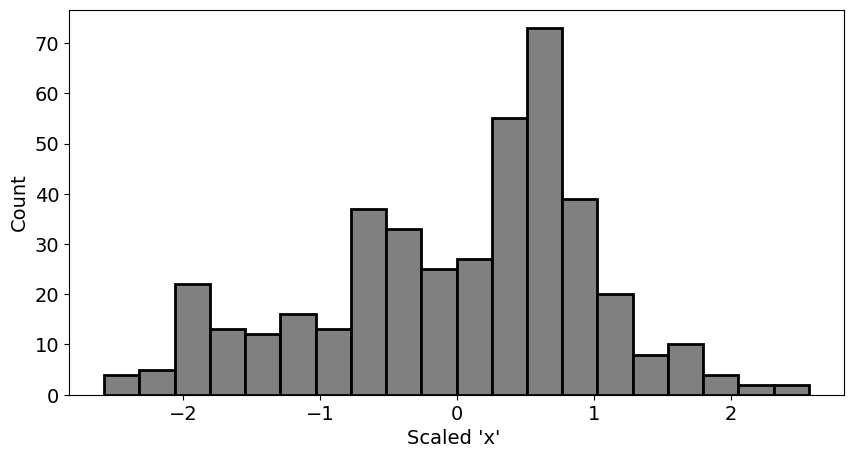

In [77]:
# Confirm the data is scaled for 'x' column

plt.figure(figsize = (10, 5))

plt.hist(CMS_calori_dataset_np_sub_scaled[:, 0], bins = 20, facecolor = 'grey', edgecolor = 'black', linewidth = 2)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Add proper x-label and y-label

# Hint: plt.xlabel("Scaled 'x'", fontsize = 14)
# Write your codes
# Hint: plt.ylabel('Count', fontsize = 14)
# Write your codes
plt.xlabel("Scaled 'x' ", fontsize = 14)
plt.ylabel('Count', fontsize = 14)
plt.show()

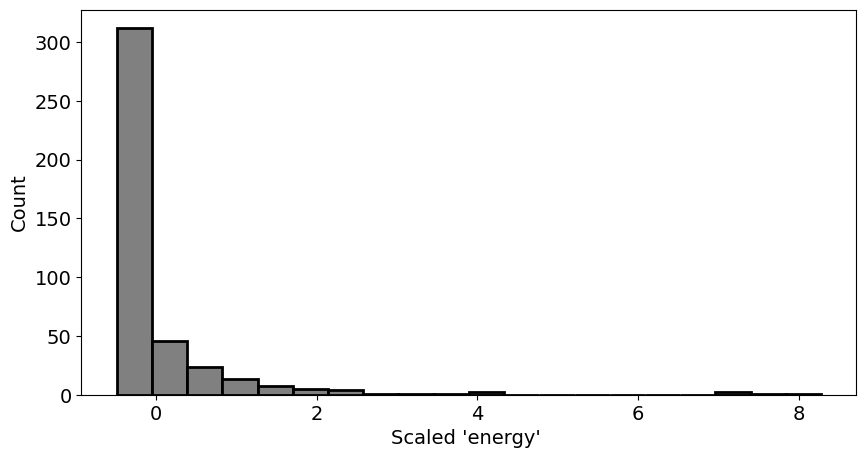

In [78]:
# Confirm the data is scaled for 'energy' column

plt.figure(figsize = (10, 5))

plt.hist(CMS_calori_dataset_np_sub_scaled[:, 5], bins = 20, facecolor = 'grey', edgecolor = 'black', linewidth = 2)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Add proper x-label and y-label

# Hint: same as the cell above, but for 'energy'
# Write your codes
# Write your codes
plt.xlabel("Scaled 'energy' ", fontsize = 14)
plt.ylabel('Count', fontsize = 14)
plt.show()

### Expected histogram outputs - Feel free to style your plot differently

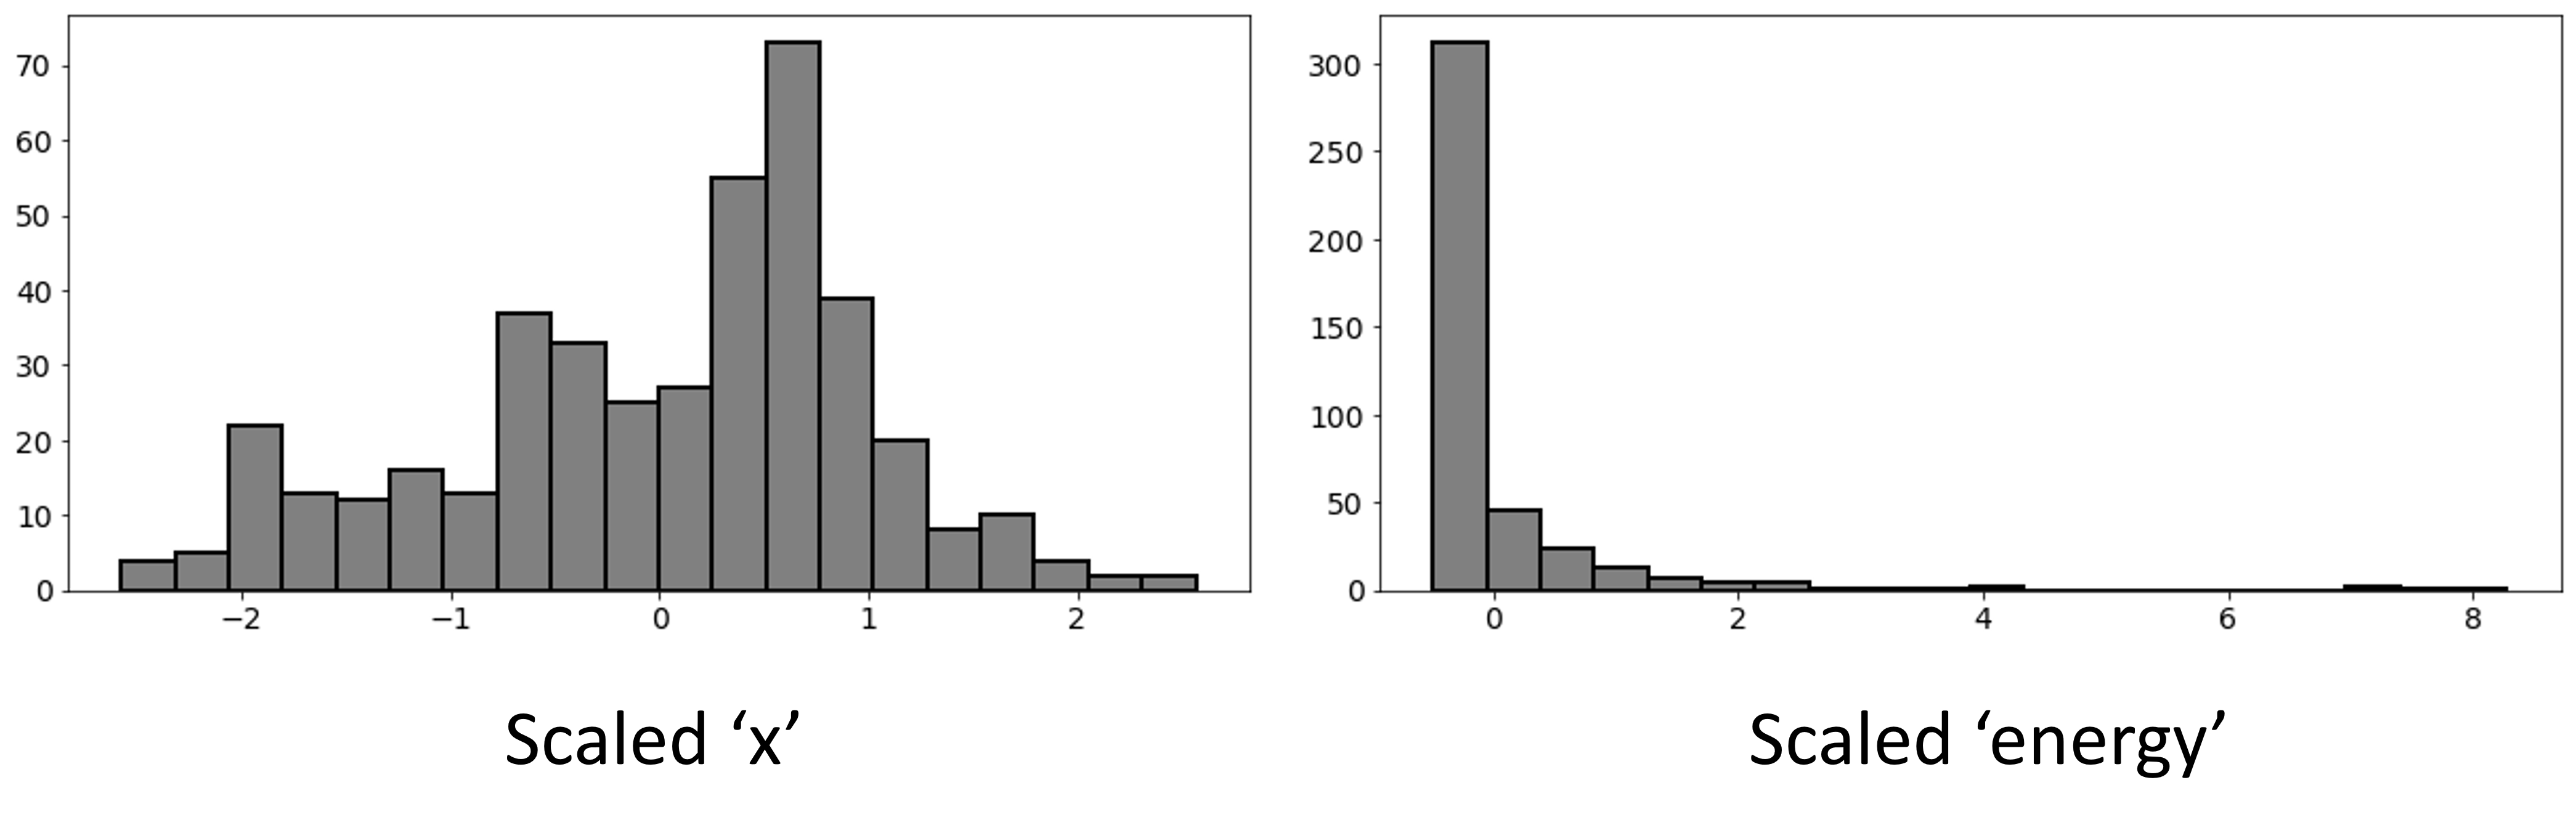

In [79]:
Image('lab1_e1_expected_outputs.png', width = 1000)

---
# Part 2: Data Splitting and the Iris Dataset (~50 min)

| Task | Description | Time |
|---|---|---|
| 2.1 | Write the `split_data()` function | ~20 min |
| 2.2 | Test the function and check the shapes | ~10 min |
| 2.3 | Load and visualize the Iris dataset | ~10 min |
| 2.4 | Scale the Iris features with your `scale_data()` from Part 1 | ~10 min |

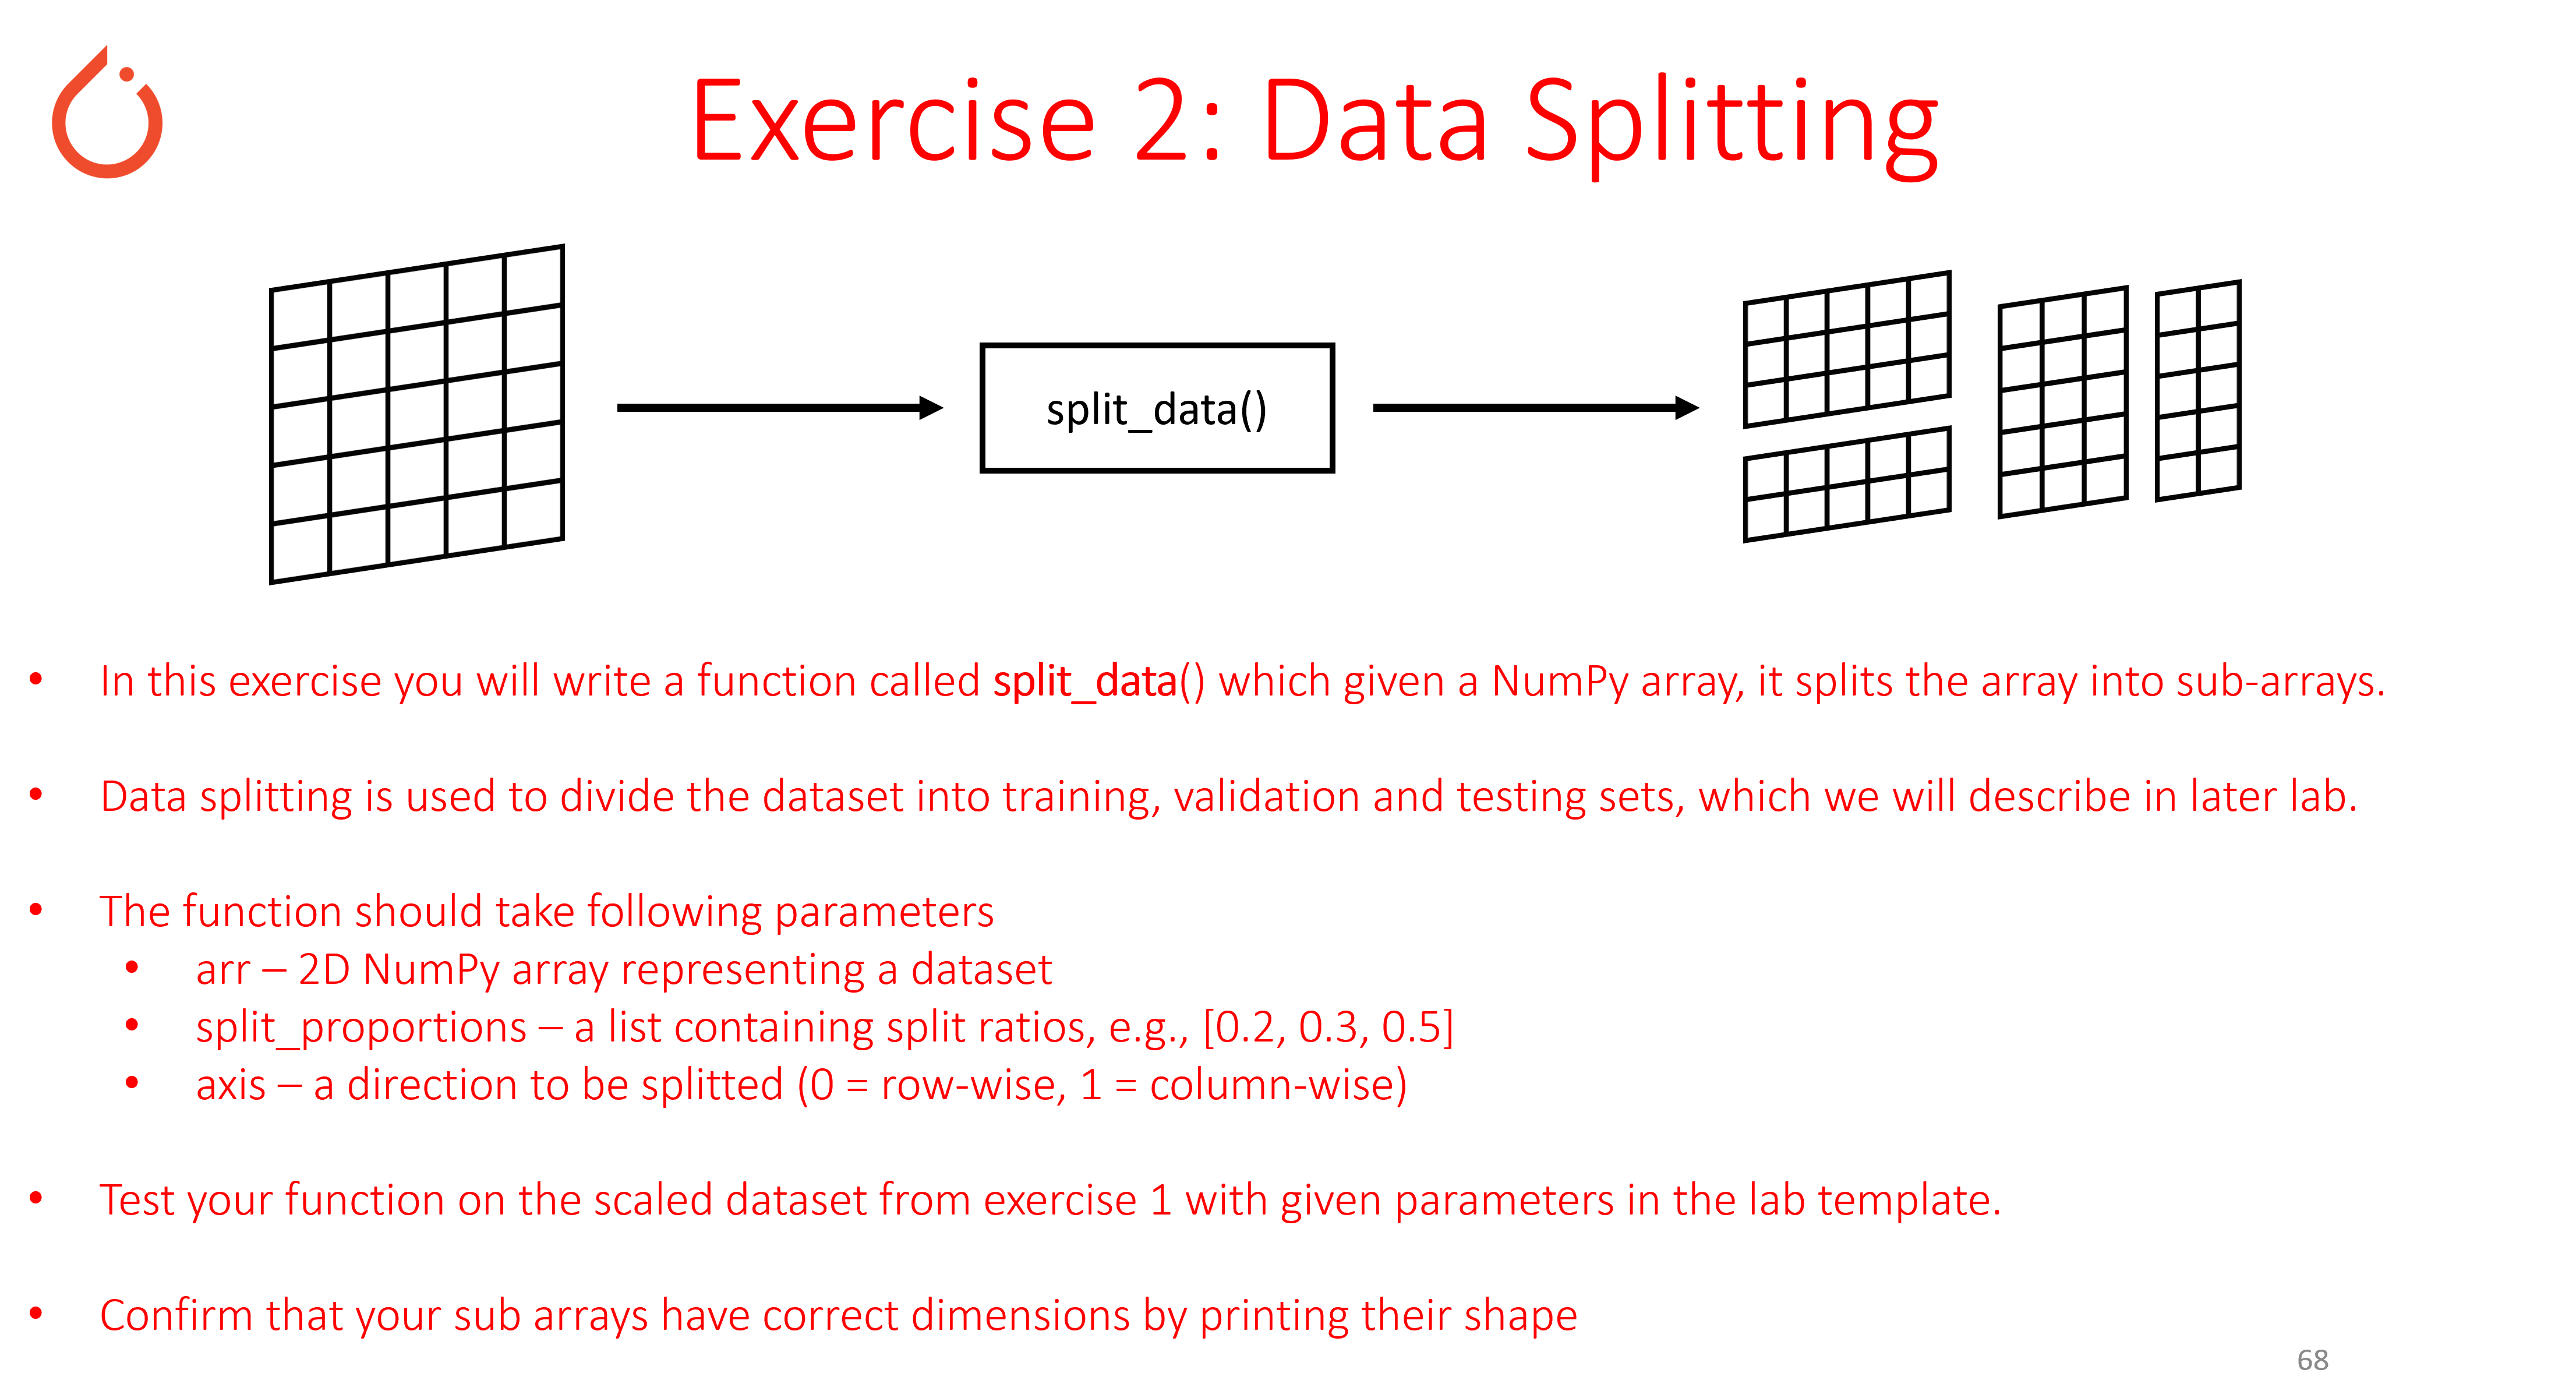

In [80]:
Image('lab1_exercise2.png', width = 1000)

## Task 2.1: Create the Splitting Function

In [81]:
# Create the splitting function

def split_data(arr, split_proportions, axis):

    # Returns a list of numpy sub-arrays according to split proportions

    # Step 1: number of rows (axis = 0) or columns (axis = 1) in arr
    # Hint: arr.shape[axis]
    n = arr.shape[axis] # Write your codes

    # Step 2: running total of the proportions, e.g. [0.6, 0.2, 0.2] -> [0.6, 0.8, 1.0]
    # Hint: np.cumsum(split_proportions)
    cumulative = np.cumsum(split_proportions) # Write your codes

    # Step 3: positions where the array is cut, e.g. [0.6, 0.8] x 420 -> [252, 336] (already done for you)
    split_indices = np.round(cumulative[:-1] * n).astype(int)

    # Step 4: cut the array at those positions
    # Hint: np.split(arr, split_indices, axis = axis)
    split_data_list = np.split(arr, split_indices, axis = axis) # Write your codes

    return split_data_list

## Task 2.2: Test the Splitting Function

In [82]:
# Test your split function against scaled CMS Calorimeter dataset from Part 1

sub_data_list_1 = split_data(arr = CMS_calori_dataset_np_sub_scaled,
                                    split_proportions = [0.6, 0.2, 0.2], axis = 0)

In [83]:
# Confirm that dataset has been split into correct shapes
# The correct dimensions should be (252, 6) (84, 6) (84, 6)

print(sub_data_list_1[0].shape, sub_data_list_1[1].shape, sub_data_list_1[2].shape)

(252, 6) (84, 6) (84, 6)


In [84]:
# Test your split function against scaled CMS Calorimeter dataset from Part 1

sub_data_list_2 = split_data(arr = CMS_calori_dataset_np_sub_scaled,
                                                split_proportions = [0.5, 0.5], axis = 1)

In [85]:
# Confirm that dataset has been split into correct shapes
# The correct dimensions should be (420, 3) (420, 3)

print(sub_data_list_2[0].shape, sub_data_list_2[1].shape)

(420, 3) (420, 3)


## Task 2.3: Prepare Data - Iris Dataset

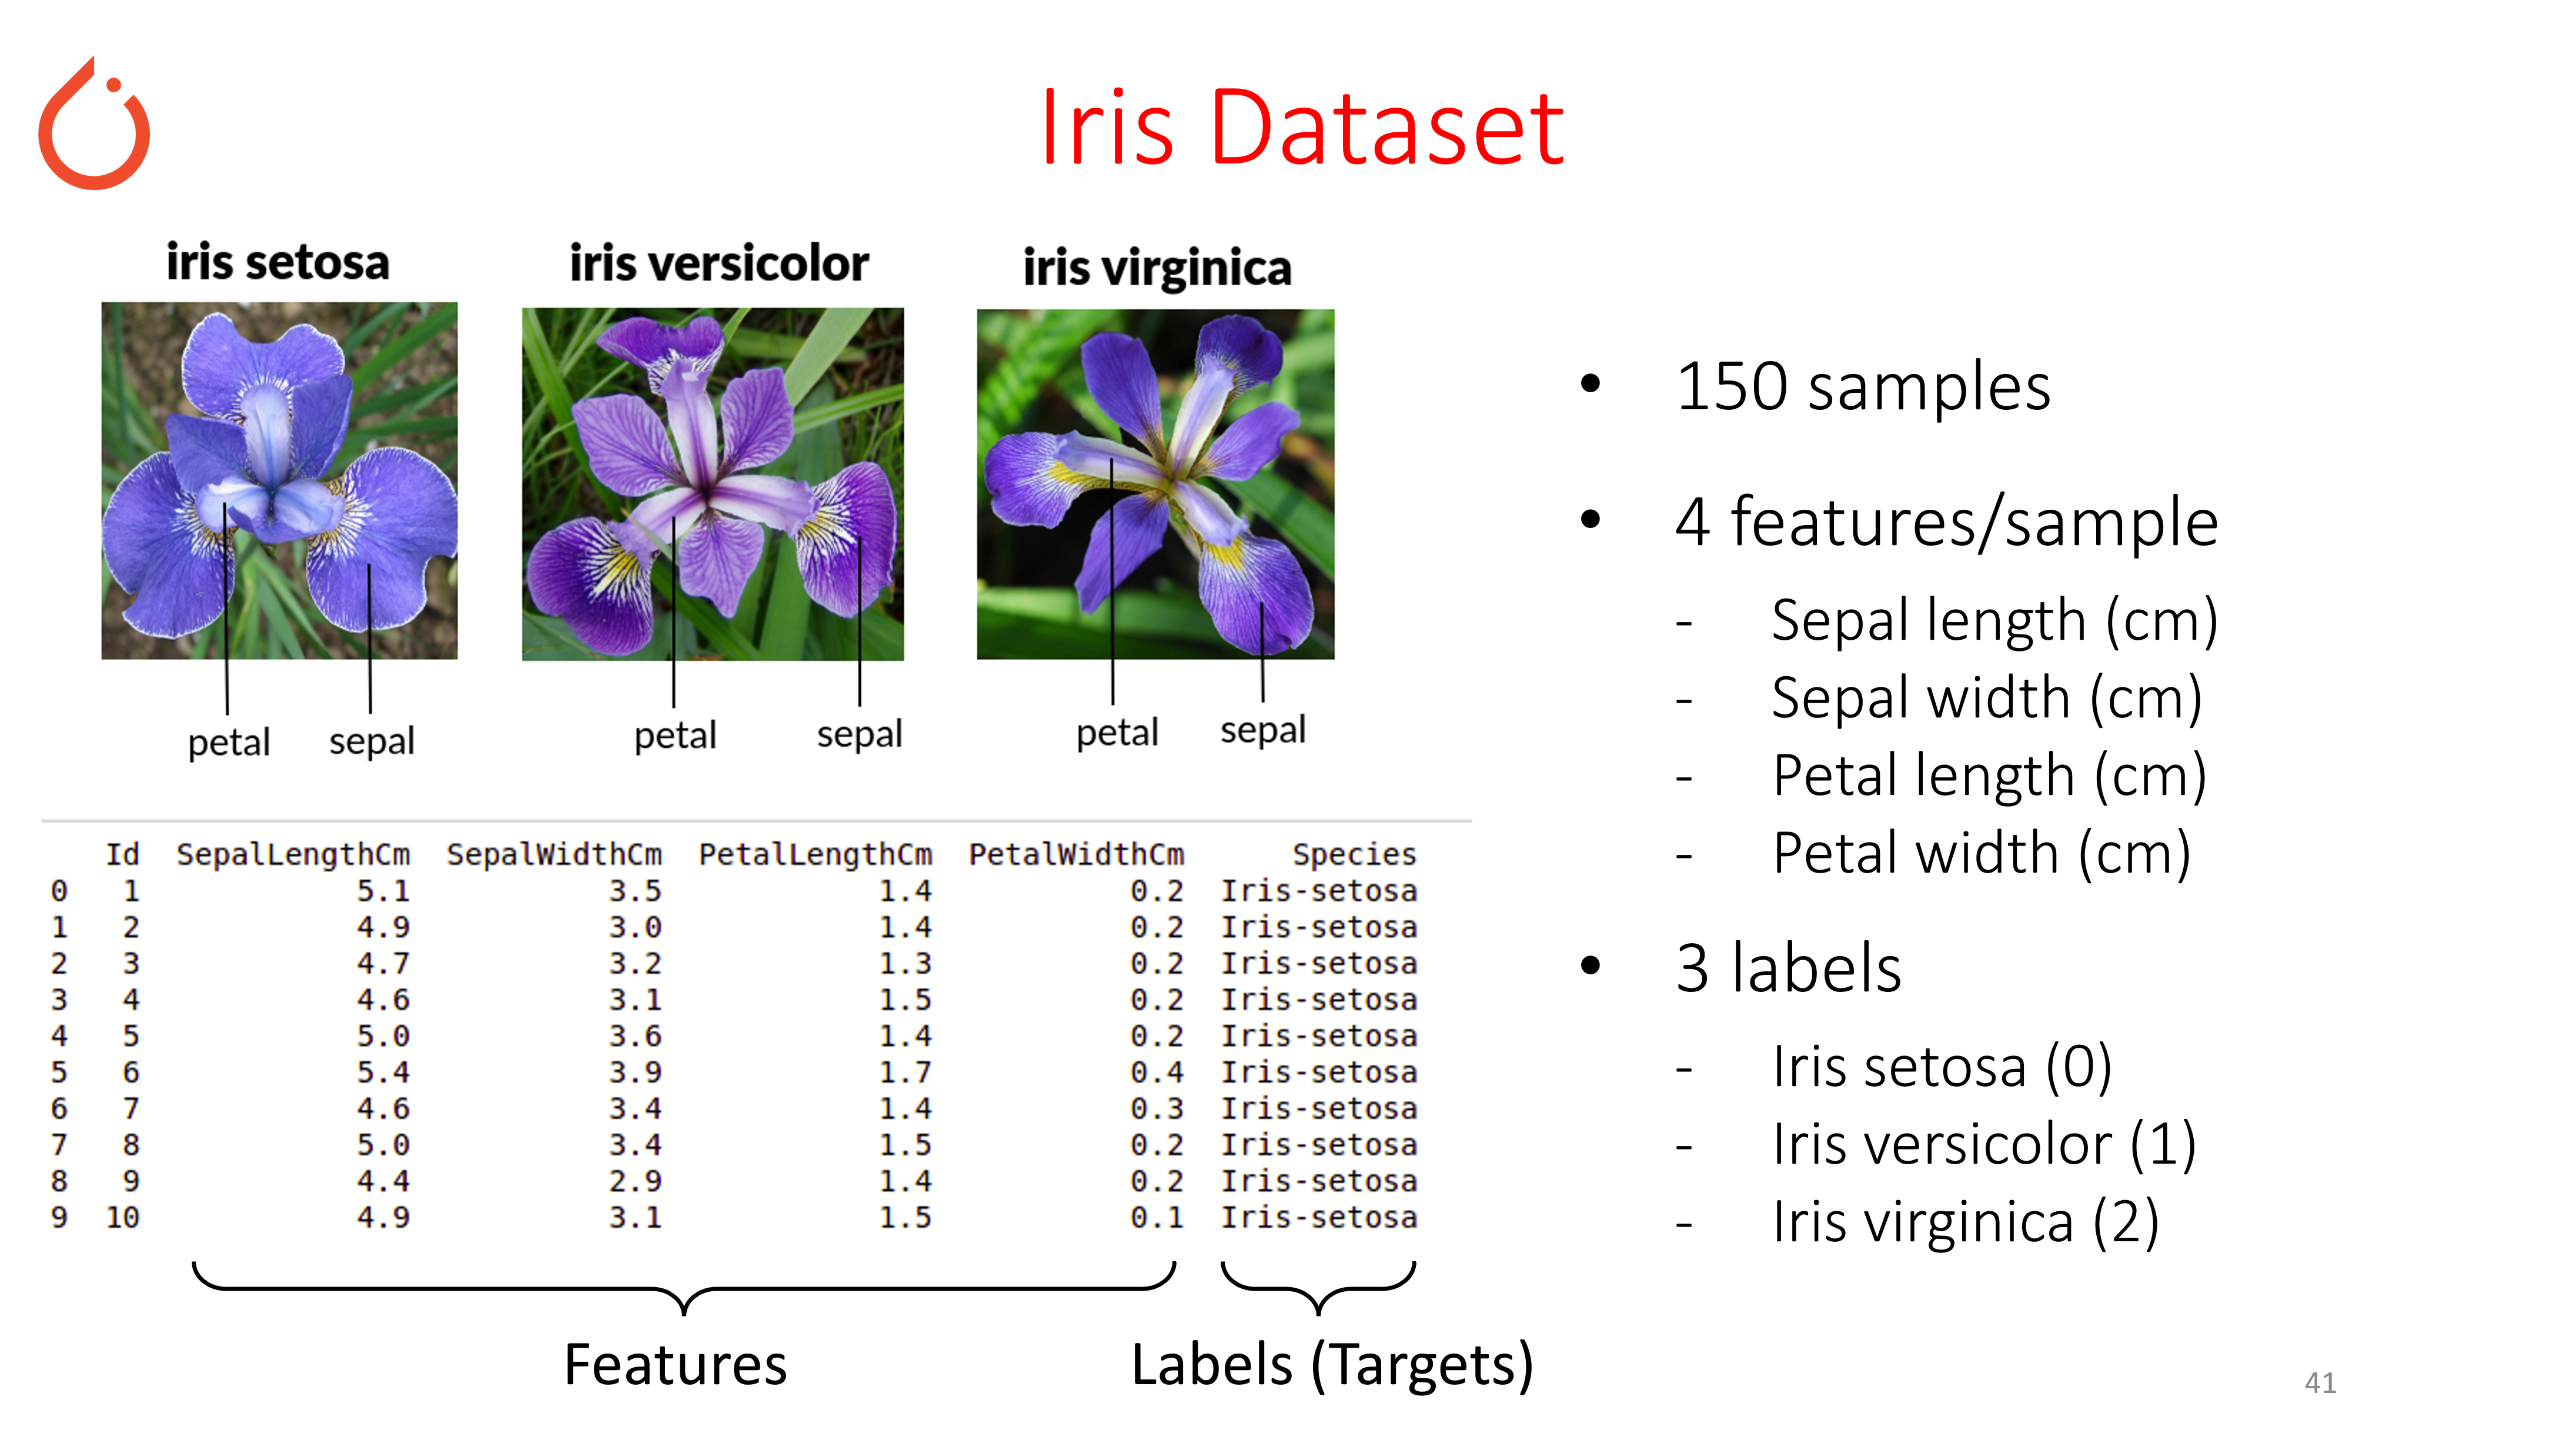

In [86]:
Image('iris_dataset.png', width = 1000)

In [87]:
from sklearn.datasets import load_iris

# iris dataset is available from scikit-learn package
iris = load_iris()

# Load the X (features) and y (targets) for training
X_train = iris['data']
y_train = iris['target']

# Load the name labels for features and targets
feature_names = iris['feature_names']
names = iris['target_names']

In [88]:
# Print the first 10 training samples for both features and targets

print(X_train[:10, :], y_train[:10])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]] [0 0 0 0 0 0 0 0 0 0]


In [89]:
# Print the dimensions of features and targets

print(X_train.shape, y_train.shape)

(150, 4) (150,)


In [90]:
# feature_names contains name for each column in X_train
# For targets, 0 -> setosa, 1 -> versicolor, 2 -> virginica

print(feature_names, names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] ['setosa' 'versicolor' 'virginica']


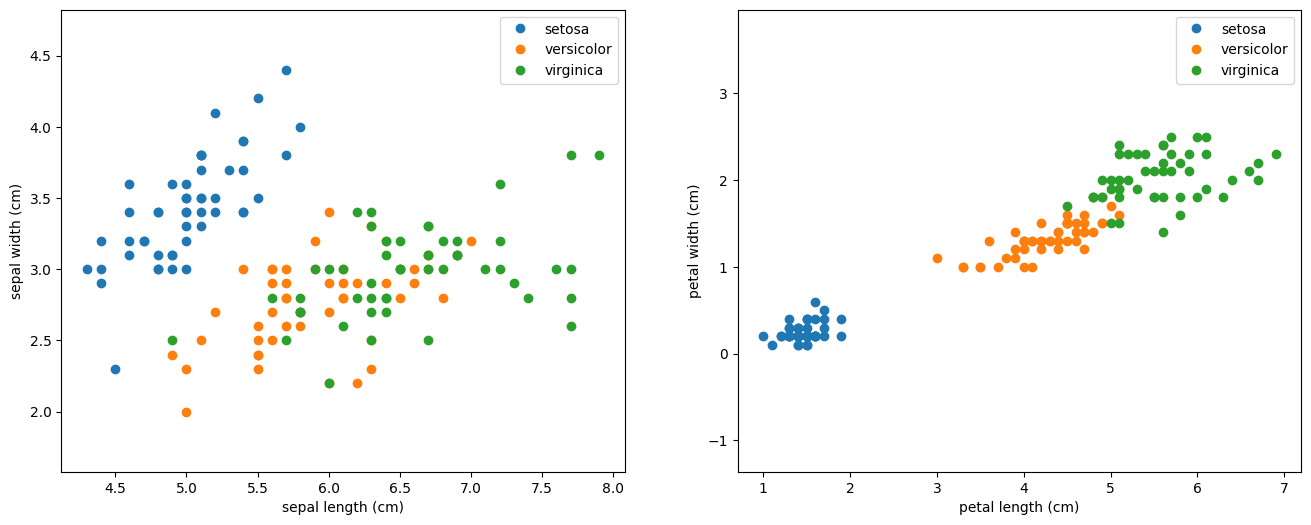

In [91]:
# We can visualize the dataset before training

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# enumerate picks up both the index (0, 1, 2) and the element ('setosa', 'versicolor', 'virginica') from "names"
# loop 1: target = 0, target_name = 'setosa'
# loop 2: target = 1, target_name = 'versicolor' etc

for target, target_name in enumerate(names):

    # Subset the rows of X_train that fall into each flower category using boolean mapping
    X_plot = X_train[y_train == target]

    # Plot the sepal length versus sepal width for the flower category
    ax1.plot(X_plot[:, 0], X_plot[:, 1], linestyle='none', marker='o', label=target_name)

# Label the plot
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.axis('equal')
ax1.legend()

# Repeat the above process but with petal length versus petal width
for target, target_name in enumerate(names):

    X_plot = X_train[y_train == target]

    ax2.plot(X_plot[:, 2], X_plot[:, 3], linestyle='none', marker='o', label=target_name)

ax2.set_xlabel(feature_names[2])
ax2.set_ylabel(feature_names[3])
ax2.axis('equal')
ax2.legend()

## Task 2.4: Scale the Iris Features

In [92]:
# Perform standard scaling on the Iris features using your scale_data() function from Part 1
# Scaled data makes it easier for the model in Part 3 to learn

# Hint: scale_data(X_train)
X_train = scale_data(X_train) # Write your codes

# Check: every column should now have mean = 0 and standard deviation = 1
print('Mean of each column:', np.round(X_train.mean(axis = 0), 3))
print('Std of each column: ', np.round(X_train.std(axis = 0), 3))

Mean of each column: [-0. -0. -0. -0.]
Std of each column:  [1. 1. 1. 1.]


---
# Part 3: Iris Classification using Regression - Fit Your First Model (~50 min)

| Task | Description | Time |
|---|---|---|
| 3.1 | Define the model | ~10 min |
| 3.2 | Define the hyperparameters | ~5 min |
| 3.3 | Identify the tracked values | ~5 min |
| 3.4 | Train the model | ~15 min |
| 3.5 | Visualize and evaluate the model (goal: training accuracy >90% under 50 epochs) | ~15 min |
| Bonus | Optional challenges | optional |

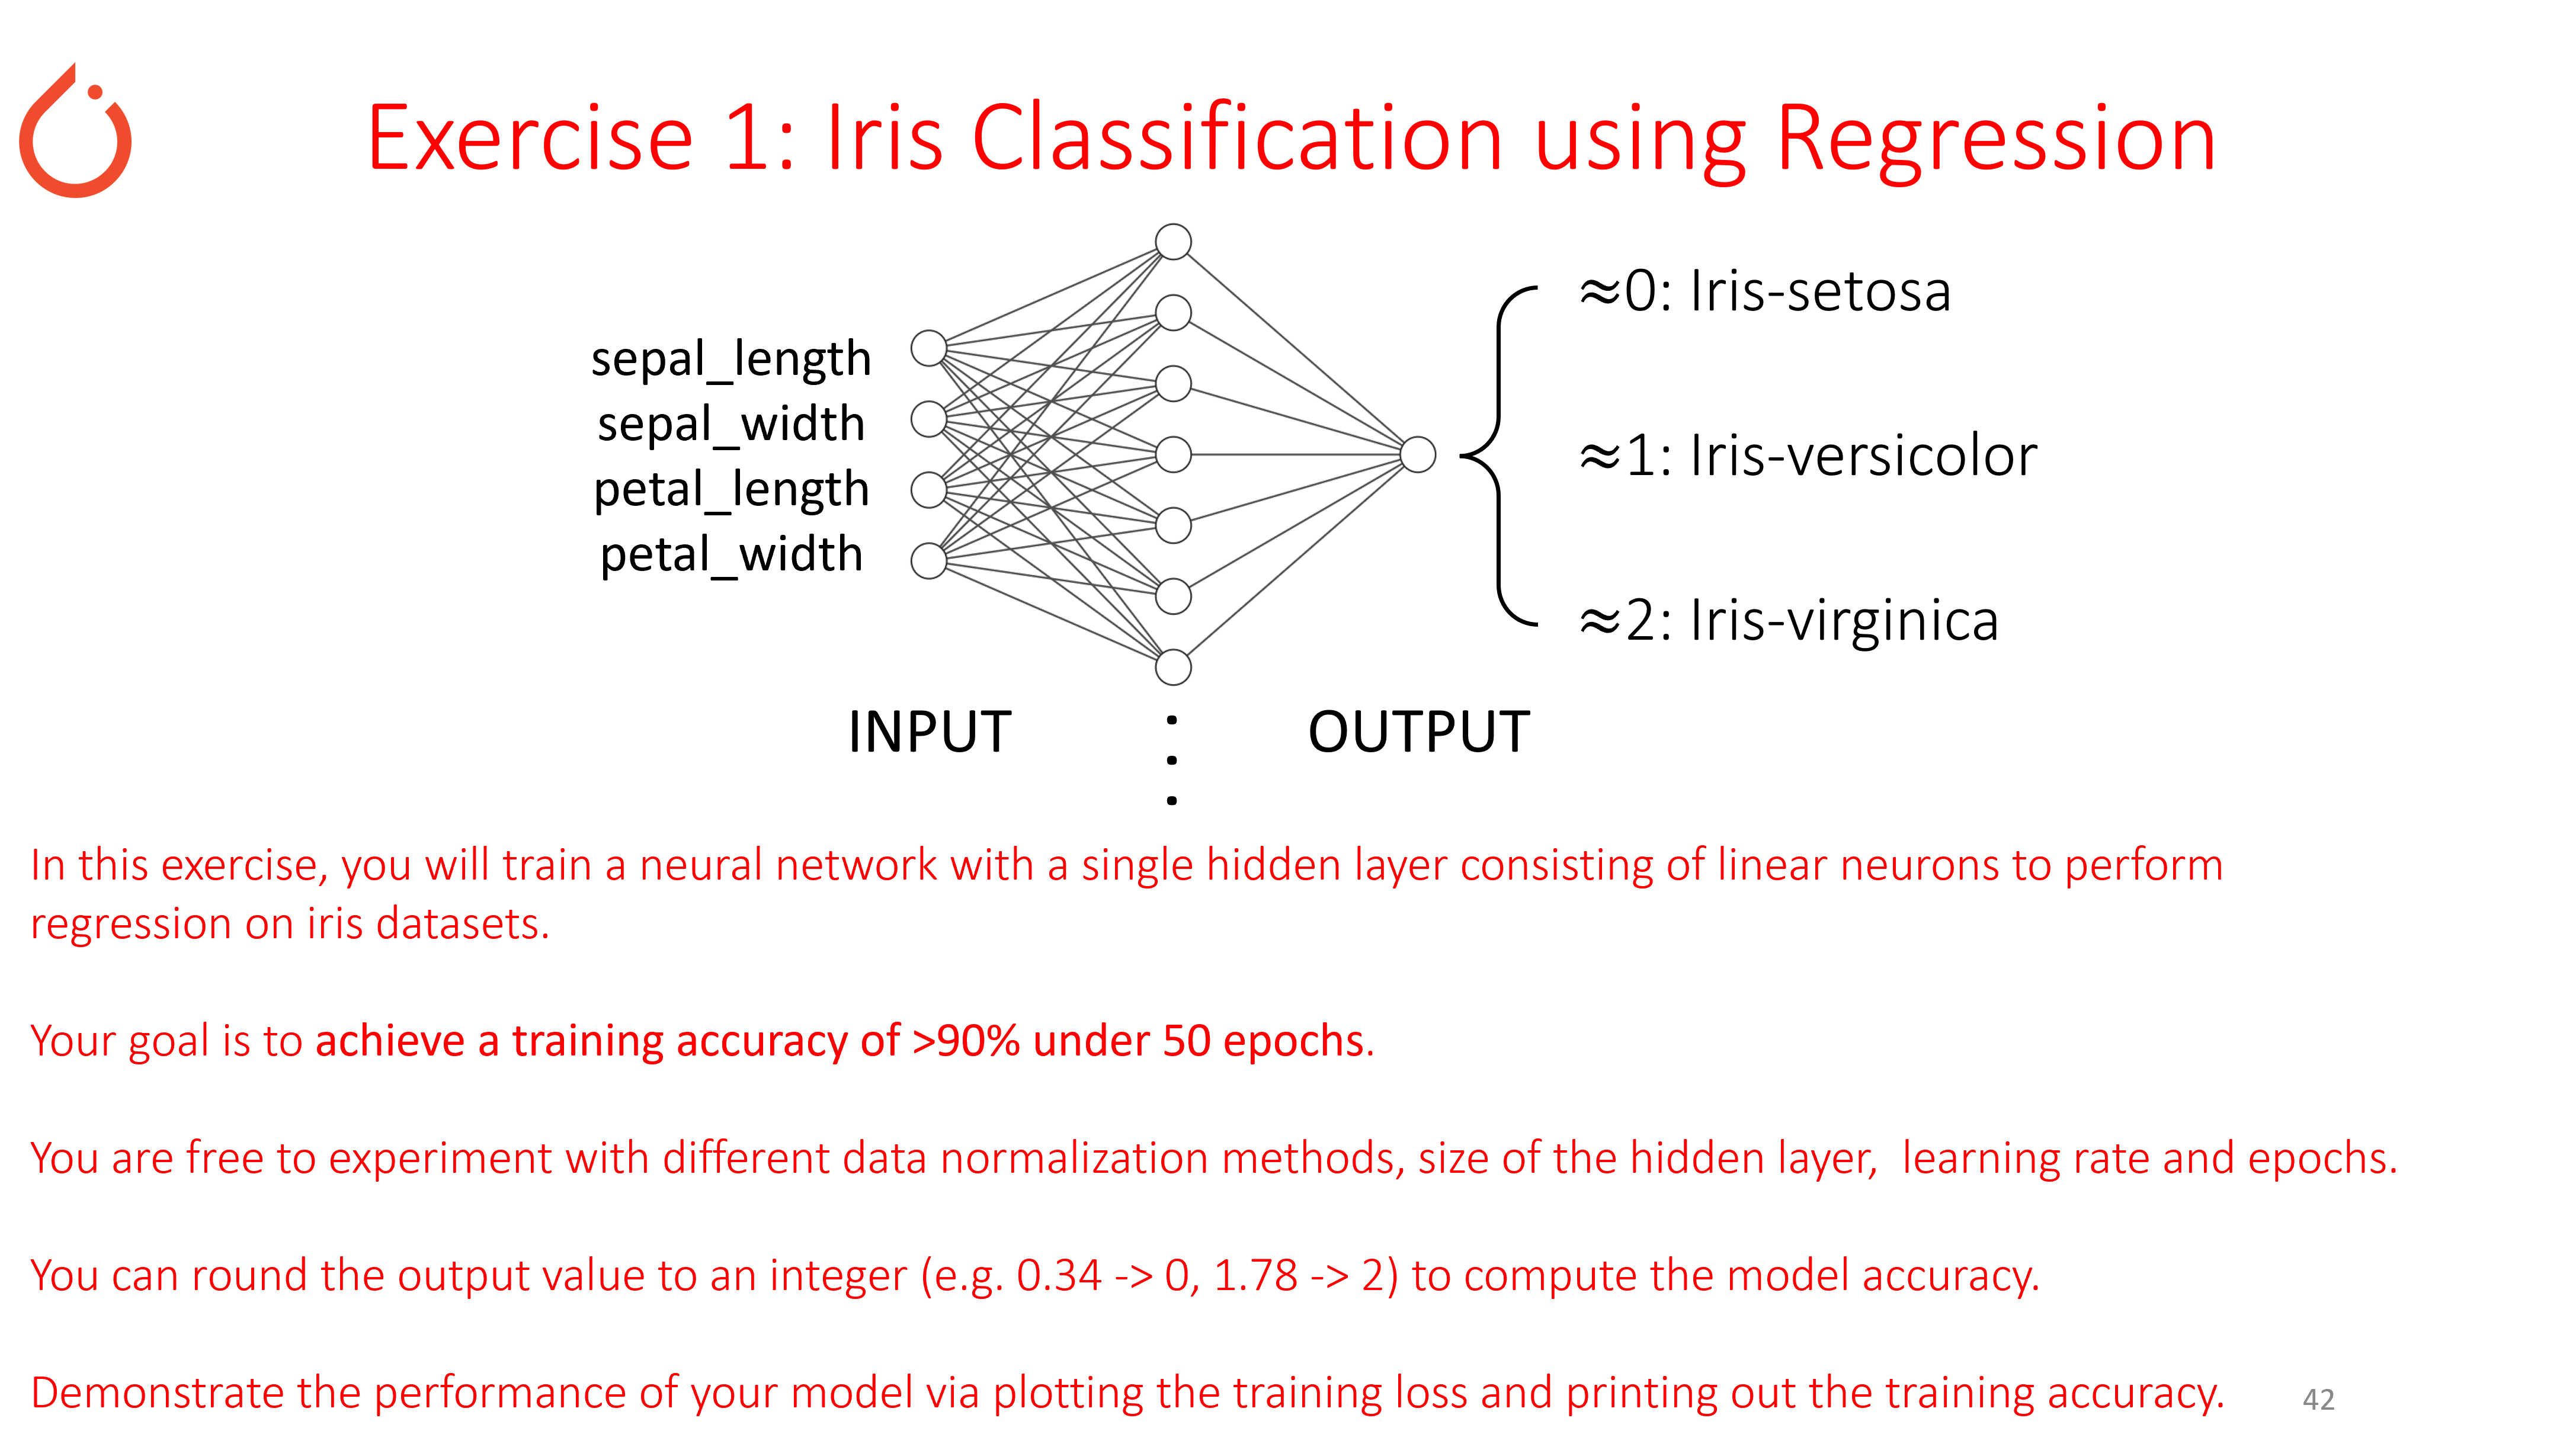

In [93]:
Image('lab2_exercise1.png', width = 1000)

## Task 3.1: Define Model

In [94]:
# A neural network with a single hidden layer of linear neurons
#   layer1: input (4 features) -> hidden layer (10 neurons)
#   layer2: hidden layer (10 neurons) -> output (1 number)

class irisClassification(torch.nn.Module):

    def __init__(self, input_dim, output_dim):

        super(irisClassification, self).__init__()

        # Hint: torch.nn.Linear(input_dim, 10)
        self.layer1 = torch.nn.Linear(input_dim,10) # Write your codes

        # Hint: torch.nn.Linear(10, output_dim)
        self.layer2 = torch.nn.Linear(10,output_dim) # Write your codes

    def forward(self, x):

        out = self.layer1(x)                    # Done for you: pass the input through layer1
        # Hint: self.layer2(out)
        out = self.layer2(out) # Write your codes

        return out

## Task 3.2: Define Hyperparameters

In [95]:
# Hint: number of features per flower (4)
input_dim = 4 # Write your codes

# Hint: the model outputs a single number (1)
output_dim = 1 # Write your codes

model = irisClassification(input_dim, output_dim)

# Hint: 0.1
learning_rate = 0.1 # Write your codes

# Hint: 45 (This has to be <50)
epochs  = 45 # Write your codes

# We will use gradient descent for our optimizer and Mean Squared Error Loss function
loss_func = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

## Task 3.3: Identify Tracked Values

In [96]:
# follow models performance over each epoch. Identify a metric and track it over epochs
# Here we track the training loss: create an empty list to store the loss of each epoch

# Hint: []
train_loss_list = [] # Write your codes

## Task 3.4: Train Model

In [97]:
import torch

# Convert to tensor only if they are still numpy arrays
if isinstance(X_train, np.ndarray):
    X_train = torch.from_numpy(X_train).float()
if isinstance(y_train, np.ndarray):
    y_train = torch.from_numpy(y_train).float()

for epoch in range(epochs):

    # Step 1: make predictions (done for you). squeeze() turns the shape (150, 1) into (150,) to match y_train
    outputs = model(X_train).squeeze()

    # Step 2: compute the loss between the predictions and the targets
    # Hint: loss_func(outputs, y_train)
    loss = loss_func(outputs, y_train) # Write your codes

    # Step 3: reset the gradients (done for you)
    optimizer.zero_grad()

    # Step 4: compute the gradients
    # Hint: loss.backward()
    # Write your codes
    loss.backward()

    # Step 5: update the model weights
    # Hint: optimizer.step()
    # Write your codes
    optimizer.step()

    # Step 6: save the loss of this epoch in the list
    # Hint: train_loss_list.append(loss.item())
    # Write your codes
    train_loss_list.append(loss.item())

    print('Epoch:', epoch, 'Loss:', loss.item())

Epoch: 0 Loss: 2.1250147819519043
Epoch: 1 Loss: 0.6870909929275513
Epoch: 2 Loss: 0.2858821153640747
Epoch: 3 Loss: 0.15631403028964996
Epoch: 4 Loss: 0.11064642667770386
Epoch: 5 Loss: 0.09135953336954117
Epoch: 6 Loss: 0.08141761273145676
Epoch: 7 Loss: 0.07551988959312439
Epoch: 8 Loss: 0.07170537114143372
Epoch: 9 Loss: 0.06907812505960464
Epoch: 10 Loss: 0.06716232001781464
Epoch: 11 Loss: 0.06568516790866852
Epoch: 12 Loss: 0.06448501348495483
Epoch: 13 Loss: 0.06346466392278671
Epoch: 14 Loss: 0.06256521493196487
Epoch: 15 Loss: 0.06175074726343155
Epoch: 16 Loss: 0.06099913269281387
Epoch: 17 Loss: 0.06029662489891052
Epoch: 18 Loss: 0.059634458273649216
Epoch: 19 Loss: 0.059006959199905396
Epoch: 20 Loss: 0.05841027572751045
Epoch: 21 Loss: 0.0578417032957077
Epoch: 22 Loss: 0.057299207895994186
Epoch: 23 Loss: 0.05678121745586395
Epoch: 24 Loss: 0.05628643184900284
Epoch: 25 Loss: 0.05581369996070862
Epoch: 26 Loss: 0.0553620420396328
Epoch: 27 Loss: 0.05493052303791046
Epoc

## Task 3.5: Visualize and Evaluate Model

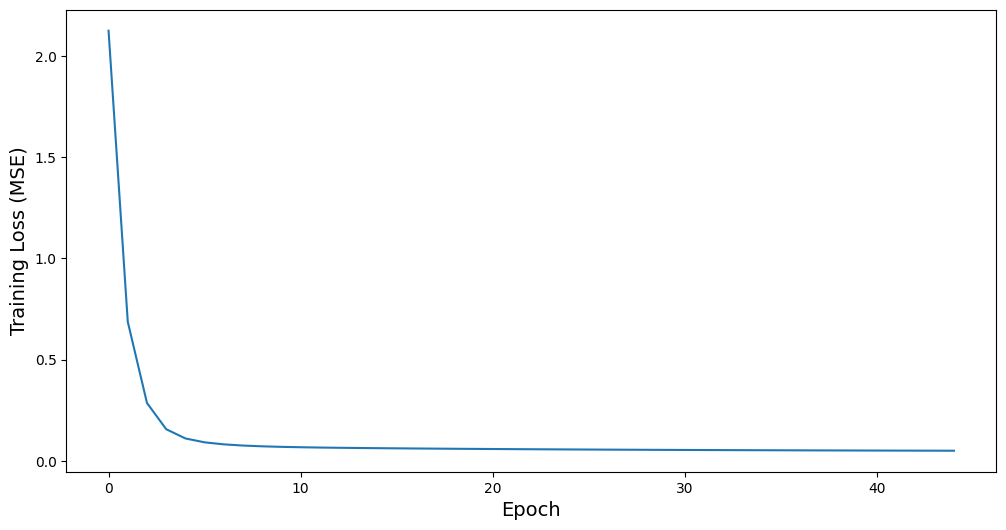

In [98]:
# Plot your training loss throughout the training
# Include proper x and y labels for the plot

plt.figure(figsize=(12, 6))

# Hint: plt.plot(train_loss_list)
# Write your codes
# Hint: plt.xlabel('Epoch', fontsize = 14)
# Write your codes
# Hint: plt.ylabel('Training Loss (MSE)', fontsize = 14)
# Write your codes
plt.plot(train_loss_list)
plt.xlabel('Epoch', fontsize = 14)
plt.ylabel('Training Loss (MSE)', fontsize = 14)
plt.show()

In [99]:
# Confirm that your model's training accuracy is >90%

with torch.no_grad():

    # Compare your model predictions with targets (y_train) to compute the training accuracy
    # Hint: model(X_train).squeeze()
    y_pred = model(X_train).squeeze()  # Write your codes

# Training accuracy = (# of correct predictions) / (total # of training samples)
# You can round the model predictions to integer (e.g. 0.34 -> 0, 1.78 -> 2)

# Hint: torch.round(y_pred)
y_pred_rounded = torch.round(y_pred) # Write your codes

correct = (y_pred_rounded == y_train).sum().item()     # Done for you: number of correct predictions

# Hint: correct / len(y_train)
accuracy = correct / len(y_train) # Write your codes

print('Training accuracy:', accuracy * 100, '%')

Training accuracy: 97.33333333333334 %


---
# Bonus (Optional)

These challenges are **not required**. They are for students who finish early and want an extra challenge.

### Bonus 1: Experiment with the Model Settings

You are free to experiment with different data normalization methods, size of the hidden layer, learning rate and epochs. Can you still reach a training accuracy of >90% under 50 epochs?

Ideas to try:
* Skip Task 2.4 (train on the **unscaled** Iris features). What happens to the loss with the same learning rate?
* Change the hidden layer size (the `10` in Task 3.1).
* Change `learning_rate` and `epochs` in Task 3.2. What is the smallest number of epochs that still gives >90%?

To try a new setting, change the value, then re-run the cells from **Task 2.3** onward (the data must be reloaded each time).

Record your results in the table below:

| Scaled data? | Hidden layer size | Learning rate | Epochs | Training accuracy |
|---|---|---|---|---|
| Yes | 10 | 0.1 | 45 | |
| | | | | |
| | | | | |

### Bonus 2: Track a Second Metric

In Task 3.3 we only tracked the training loss. Also track the **training accuracy** over the epochs, then plot it with proper x and y labels.

No hints for this one. You can reuse the code from Task 3.5 inside the training loop.

In [100]:
# Bonus 2: track and plot the training accuracy over epochs

# Write your codes